## Детекция клеток

Ваша задача: обучить YOLO для детекции дрожжевых клеток и микроструктур (см. [07_object_detection.ipynb](../workshops/07_object_detection.ipynb)). Всё необходимое для запуска обучения вы можете взять из ноутбука с практикой, доделать нужно будет самую малость:
- реализовать расчёт Mean Average Precision для всего валидационного сета
- попробовать привести regression loss к виду, который используется в Yolo9000 и YoloV3
- подобрать лучшие размеры якорных рамок с помощью кластеризации

Основная цель: любыми средствами добиться $mAP > 0.6$ на валидации.

Используйте класс `torchmetrics.detection.MeanAveragePrecision` для расчёта $mAP$.

Нас будет интересовать именно значение `map` в словаре со всеми метриками - это mean average precision, усреднённый по всем отсечкам intersection over union в диапазоне $[0.5, 0.95]$ (см. документацию к классу).

При решении можно пользоваться `lightning` или писать цикл обучения вручную. В последнем случае не забудьте вручную отправить модель и батчи на GPU, чтобы обучалось быстрее

In [418]:
#! wget https://tudatalib.ulb.tu-darmstadt.de/bitstream/handle/tudatalib/3799/yeast_cell_in_microstructures_dataset.zip
#! unzip yeast_cell_in_microstructures_dataset.zip -d yeast_cell_in_microstructures_dataset
#! pip install torchmetrics

In [419]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [420]:
from pathlib import Path

import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.figure import Figure
from torch import Tensor, nn
from torch.utils.data import DataLoader, Dataset
from torchmetrics.functional.detection import intersection_over_union
from torchvision.ops.boxes import box_convert
torch.manual_seed(42)

In [421]:
def process_yolo_preds(preds: Tensor, rescaled_anchors: Tensor) -> tuple[Tensor, Tensor, Tensor]:
    """
    Преобразование выходов модели в
    1. Логит наличия объекта (вероятность получается применением сигмоиды)
    2. Положение рамки относительно ячейки в формате cxcywh
    3. Логиты классов (вероятности получаются применением softmax)
    """
    rescaled_anchors = rescaled_anchors.view(1, len(rescaled_anchors), 1, 1, 2)
    box_predictions = preds[..., 1:5].clone()

    box_predictions[..., 0:2] = torch.sigmoid(box_predictions[..., 0:2])
    box_predictions[..., 2:] = torch.exp(box_predictions[..., 2:]) * rescaled_anchors

    scores = preds[..., 0:1]
    return scores, box_predictions, preds[..., 5:]

In [422]:
GRID_SIZE = 8
IMAGE_SIZE = 256
ANCHORS = [
    [48, 72],
    # [64, 64],
    # [72, 48],
]

rescaled_anchors = torch.tensor(ANCHORS).to(device) / IMAGE_SIZE * GRID_SIZE

In [423]:
class CNNBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, **kwargs):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, bias=False, **kwargs)
        self.bn = nn.BatchNorm2d(out_channels)
        self.activation = nn.LeakyReLU(0.1)

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        return self.activation(x)

class TinyYOLO(nn.Module):
    def __init__(self, num_classes: int = 2, num_anchors: int = 1, in_channels: int = 1) -> None:
        super().__init__()
        self.num_classes = num_classes
        self.in_channels = in_channels
        self.num_anchors = num_anchors
        self.layers = nn.Sequential(
            CNNBlock(1, 16, kernel_size=3, stride=2, padding=1, dilation=2),
            CNNBlock(16, 32, kernel_size=3, stride=2, padding=1, dilation=2),
            CNNBlock(32, 64, kernel_size=3, stride=2, padding=1, dilation=2),
            CNNBlock(64, 128, kernel_size=3, stride=2, padding=1, groups=8),
            CNNBlock(128, 256, kernel_size=3, stride=1, padding=1, groups=8),
            CNNBlock(256, 256, kernel_size=3, stride=1, padding=1, groups=16),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(256, num_anchors * (num_classes + 5), kernel_size=1)
        )

    def forward(self, x: Tensor) -> Tensor:
        x = self.layers(x)
        B, _, W, H = x.shape
        x = x.view(B, self.num_anchors, self.num_classes + 5, W, H)  # B A F W H
        x = x.permute(0, 1, 3, 4, 2)  # B A W H F
        return x


model = TinyYOLO(in_channels=1, num_anchors=1, num_classes=2)
print(sum(p.numel() for p in model.parameters()))
model.forward(torch.randn(2, 1, 256, 256)).shape

109431


torch.Size([2, 1, 8, 8, 7])

In [424]:
def iou_wh(wh1: Tensor, wh2: Tensor) -> Tensor:
    # IoU based on width and height of bboxes

    # intersection
    intersection_area = torch.min(wh1[..., 0], wh2[..., 0]) * torch.min(wh1[..., 1], wh2[..., 1])

    # union
    box1_area = wh1[..., 0] * wh1[..., 1]
    box2_area = wh2[..., 0] * wh2[..., 1]
    union_area = box1_area + box2_area - intersection_area

    iou_score = intersection_area / union_area
    return iou_score


def boxes_to_cells(
    boxes: Tensor,
    classes: Tensor,
    rescaled_anchors: Tensor,
    grid_size: int = 8,
    ignore_iou_thresh: float = 0.5,
) -> Tensor:
    """
    Переводит bbox представление в клеточное представление, где каждая рамка -
    (id класса, вероятность нахождения объекта, cx, cy, w, h), а клеточное представление
    имеет размер (batch_size, n_anchors, grid_size, grid_size, 6), в последней размерности
    хранятся признаки ячейки: класс объекта, вероятность объекта, координаты и размеры рамки
    относительно ячейки

    Args:
        boxes (Tensor): тензор со всеми рамками
        classes (Tensor): тензор с id классов объектов
        rescaled_anchors (Tensor): тензор размера (n_anchors, 2) с размерами якорей в долях от размеров ячейки
        grid_size (int): размер сетки,
        ignore_iou_thresh (float, optional): значение IoU для рамок, при котором ячейка,
            занятая более чем одним объектом, будет специально помечена для игнорирования
    """
    targets = torch.zeros((len(rescaled_anchors), grid_size, grid_size, 6))

    # Каждой рамке сопоставляем клетку и наиболее подходящий якорь
    for box, class_label in zip(boxes, classes):
        iou_anchors = iou_wh(box[2:4], rescaled_anchors / grid_size)
        anchor_indices = iou_anchors.argsort(descending=True, dim=0)
        x, y, width, height = box

        # Относим рамку к наиболее подходящему якорю
        has_anchor = False
        for anchor_idx in anchor_indices:
            s = grid_size

            # Определяем клетку, к которой относится рамка
            i, j = int(s * y), int(s * x)
            anchor_taken = targets[anchor_idx, i, j, 0]

            # Проверяем, доступен ли якорная рамка для текущей ячейки
            if not anchor_taken and not has_anchor:
                # Пересчитываем координаты по отношению к клетке
                x_cell, y_cell = s * x - j, s * y - i
                width_cell, height_cell = (width * s, height * s)
                box_coordinates = torch.tensor([x_cell, y_cell, width_cell, height_cell])

                # Заполняем содержимое для выбранной клетки
                targets[anchor_idx, i, j, 0] = 1  # указатель, что в клетке есть объект
                targets[anchor_idx, i, j, 1:5] = box_coordinates
                targets[anchor_idx, i, j, 5] = int(class_label)

                has_anchor = True

            # Если якорь уже выбран, проверим IoU, если больше threshold - пометим клетку -1
            elif not anchor_taken and iou_anchors[anchor_idx] > ignore_iou_thresh:
                targets[anchor_idx, i, j, 0] = -1

    return targets

In [425]:
class YeastDetectionDataset(Dataset):
    def __init__(
        self, subset_dir: Path, anchors: list[tuple[int, int]], image_size: int, grid_size: int = 8
    ) -> None:
        super().__init__()
        self.subset_dir = subset_dir
        self.items = list((self.subset_dir / "inputs").glob("*.pt"))
        # Ignore IoU threshold
        self.ignore_iou_thresh = 0.5
        self.rescaled_anchors = torch.tensor(anchors) / image_size * grid_size
        self.grid_size = grid_size
        self.image_size = image_size

    def __len__(self) -> int:
        return len(self.items)

    def __getitem__(self, index: int) -> tuple[Tensor, Tensor]:
        image_path = self.items[index]
        # load everything
        image = torch.load(image_path, weights_only=True).unsqueeze(0)
        classes = (
            torch.load(self.subset_dir / "classes" / image_path.parts[-1], weights_only=True) + 1
        )
        boxes = torch.load(
            self.subset_dir / "bounding_boxes" / image_path.parts[-1], weights_only=True
        )
        boxes = box_convert(boxes, "xyxy", "cxcywh") / self.image_size

        # convert boxes to cells
        targets = boxes_to_cells(
            boxes, classes, self.rescaled_anchors, self.grid_size, self.ignore_iou_thresh
        )
        return image.to(device), targets.to(device)

In [426]:
train_dataset = YeastDetectionDataset(
    Path("yeast_cell_in_microstructures_dataset/train"), anchors=ANCHORS, image_size=256
)
val_dataset = YeastDetectionDataset(Path("yeast_cell_in_microstructures_dataset/val"), anchors=ANCHORS, image_size=256)

batch_size = 32
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False)

In [427]:
x, y = train_dataset[2]
y.shape

torch.Size([1, 8, 8, 6])

In [428]:
def cells_to_bboxes(cells: Tensor, rescaled_anchors: Tensor, is_predictions=False) -> Tensor:
    """
    Переводит клеточное представление в bbox представление, где каждая рамка -
    (id класса, вероятность нахождения объекта, cx, cy, w, h), а клеточное представление
    имеет размер (batch_size, n_anchors, grid_size, grid_size, 6), в последней размерности
    хранятся признаки ячейки: класс объекта, вероятность объекта, координаты и размеры рамки
    относительно ячейки

    Args:
        cells (Tensor): тензор размера (batch_size, n_anchors, width, height, 6)
        rescaled_anchors (Tensor): тензор размера (n_anchors, 2) с размерами якорей в долях от размеров ячейки
        is_predictions (bool, optional): являются ли входные ячейки предсказаниями или верной аннотацией.
    """

    if is_predictions:
        scores, box_predictions, logits = process_yolo_preds(cells, rescaled_anchors)
        scores = torch.sigmoid(scores)
        best_class = torch.argmax(logits, dim=-1).unsqueeze(-1) + 1

    else:
        box_predictions = cells[..., 1:5].clone()
        scores = cells[..., 0:1]
        best_class = cells[..., 5:6]

    # масштабируем размер рамок [0, grid_size] -> [0, 1]
    _, _, H, W, _ = cells.shape
    range_y, range_x = torch.meshgrid(
        torch.arange(H, dtype=cells.dtype, device=cells.device),
        torch.arange(W, dtype=cells.dtype, device=cells.device),
        indexing="ij",
    )
    x = torch.cat(
        [
            best_class,
            scores,
            (box_predictions[..., 0:1] + range_x[None, None, :, :, None]) / W,  # X center
            (box_predictions[..., 1:2] + range_y[None, None, :, :, None]) / H,  # Y center
            box_predictions[..., 2:3] / W,  # Width
            box_predictions[..., 3:4] / H,  # Height
        ],
        -1,
    )

    return x.view(-1, 6)

In [429]:
def plot_image(image: Tensor, boxes: Tensor, class_labels: list[str]) -> Figure:
    # назначим цвета для классов
    colour_map = plt.get_cmap("tab20b")
    colors = [colour_map(i) for i in np.linspace(0, 1, len(class_labels))]

    fig, ax = plt.subplots(1)
    ax.imshow(image, cmap="gray")
    h, w = image.shape
    for box in boxes:
        # добавляем прямоугольник
        class_pred = box[0] - 1
        box = box[2:]
        upper_left_x = box[0] - box[2] / 2
        upper_left_y = box[1] - box[3] / 2

        rect = patches.Rectangle(
            (upper_left_x * w, upper_left_y * h),
            box[2] * w,
            box[3] * h,
            linewidth=2,
            edgecolor=colors[int(class_pred)],
            facecolor="none",
        )
        ax.add_patch(rect)

        # добавляем подпись
        ax.text(
            upper_left_x * w,
            upper_left_y * h,
            s=class_labels[int(class_pred)],
            color="white",
            verticalalignment="top",
            bbox={"color": colors[int(class_pred)], "pad": 0},
        )

    return fig

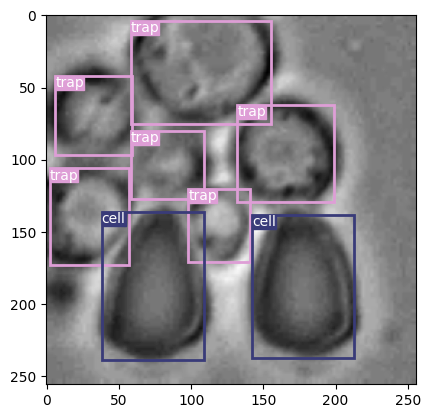

In [430]:
rescaled_anchors = torch.tensor(ANCHORS).to(device) / IMAGE_SIZE * GRID_SIZE

# Преобразуем клетки к рамкам
boxes = cells_to_bboxes(y.unsqueeze(0), rescaled_anchors).to(device)

# Оставим только рамки с объектами и нарисуем
boxes = boxes[boxes[:, 1] == 1]
fig = plot_image(x[0].to("cpu"), boxes.to("cpu"), ["cell", "trap"])
plt.show()

In [431]:
class YOLOLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.mse = nn.MSELoss()
        self.bce = nn.BCEWithLogitsLoss()
        self.cross_entropy = nn.CrossEntropyLoss()

    def forward(self, pred: Tensor, target: Tensor, anchors: Tensor) -> Tensor:
        # ниже входные тензоры будут меняться на месте, так что склонируем их
        pred = pred.clone()
        target = target.clone()

        # разделяем рамки на содержащие объекты и не содержащие
        # NB: ещё могут быть -1, куда отнеслось более 1 объекта - их не учитываем
        obj = target[..., 0] == 1
        no_obj = target[..., 0] == 0

        # преобразуем предсказания bbox
        scores, pred_boxes, logits = process_yolo_preds(pred, anchors)

        # no object loss: кросс-энтропия вместо MSE
        no_object_loss = self.bce(
            (scores[no_obj]),
            (target[..., 0:1][no_obj]),
        )

        # object loss: учим предсказывать IoU
        ious = intersection_over_union(pred_boxes[obj], target[..., 1:5][obj]).detach()
        object_loss = self.mse(scores[obj].sigmoid(), ious * target[..., 0:1][obj])

        # box coordinate loss: логарифмируем размеры рамок перед расчётом MSE
        anchors = anchors.reshape(1, len(anchors), 1, 1, 2)
        pred[..., 1:3] = pred[..., 1:3].sigmoid()
        target[..., 3:5] = torch.log(1e-6 + target[..., 3:5] / anchors)
        box_loss = self.mse(pred[..., 1:5][obj], target[..., 1:5][obj])

        # class loss: здесь всё обычно
        class_loss = self.cross_entropy(logits[obj], target[..., 5][obj].long() - 1)

        # Total loss
        return box_loss + object_loss + no_object_loss + class_loss

In [432]:
torch.manual_seed(42)
x, y = next(iter(train_loader))
model = TinyYOLO(in_channels=1, num_classes=2, num_anchors=len(rescaled_anchors)).to(device)
print(sum(p.numel() for p in model.parameters()))

preds = model.forward(x)

109431


In [433]:
loss_fn = YOLOLoss().to(device)
loss_fn.forward(preds, y, rescaled_anchors)

tensor(1.7002, device='cuda:0', grad_fn=<AddBackward0>)

In [434]:
optim = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.001)

In [435]:
for _ in range(20):
    preds = model.forward(x)
    loss = loss_fn(preds, y, rescaled_anchors)
    print(loss)
    loss.backward()
    optim.step()
    optim.zero_grad()

tensor(1.7002, device='cuda:0', grad_fn=<AddBackward0>)
tensor(1.1885, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.7444, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.6103, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.4964, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.4283, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.3420, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.3095, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.3214, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.2640, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.2382, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.2375, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.2139, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.1918, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.1833, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.1828, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.1683, device='cuda:0', grad_fn=<AddBackward0>)
tensor(0.1539, device='cuda:0', grad_fn=<AddBack

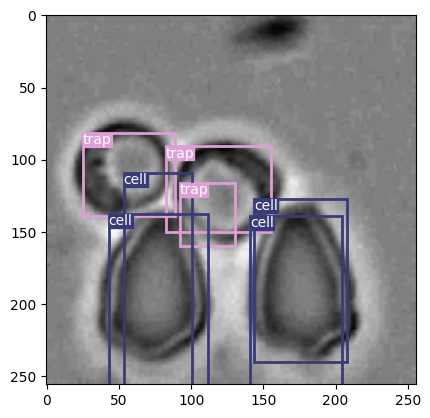

In [436]:
idx = 2
boxes = cells_to_bboxes(preds[idx].detach().unsqueeze(0), rescaled_anchors, is_predictions=True)
boxes = boxes[boxes[:, 1] > 0.2]
fig = plot_image(x[idx, 0].to("cpu"), boxes.to("cpu"), ["cell", "trap"])
plt.show()

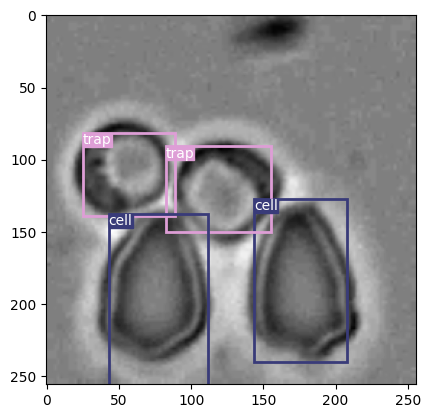

In [437]:
from torchvision.ops.boxes import nms

boxes = boxes[nms(box_convert(boxes[:, 2:], "cxcywh", "xyxy"), boxes[:, 1], iou_threshold=0.2)]
fig = plot_image(x[idx, 0].to("cpu"), boxes.to("cpu"), ["cell", "trap"])
plt.show()

In [438]:
from pprint import pprint
from torchmetrics.detection import MeanAveragePrecision

metric = MeanAveragePrecision(iou_type="bbox", box_format="cxcywh", class_metrics=True)
predicted_boxes = []
target_boxes = []
# итерируемся по элементам батча, собирая пердсказанные и верные рамки
for i in range(len(y)):
    # получаем предсказанные рамки
    pred_boxes = cells_to_bboxes(preds[i:i+1], rescaled_anchors, is_predictions=True)
    # ВАЖНО: делаем non-max suppression ДО расчёта метрик
    pred_boxes = pred_boxes[nms(box_convert(pred_boxes[:, 2:], "cxcywh", "xyxy"), pred_boxes[:, 1], iou_threshold=0.3)]
    predicted_boxes.append(
        dict(
            boxes=pred_boxes[:, 2:],
            scores=pred_boxes[:, 1],
            labels=pred_boxes[:, 0].long(),
        )
    )
    # достаём правильные рамки
    true_boxes = cells_to_bboxes(y[i:i+1], rescaled_anchors)
    true_boxes = true_boxes[true_boxes[:, 1] == 1]

    target_boxes.append(
        dict(
            boxes=true_boxes[:, 2:],
            labels=true_boxes[:, 0].long(),
        )
    )

# обновляем состояние метрики
# можно было и сразу посчитать, но мы имитируем ситуацию,
# когда метрики используется для сбора данных по всем батчам
metric.update(predicted_boxes, target_boxes)

pprint(metric.compute())


{'classes': tensor([1, 2], dtype=torch.int32),
 'map': tensor(0.5290),
 'map_50': tensor(0.9433),
 'map_75': tensor(0.5885),
 'map_large': tensor(-1.),
 'map_medium': tensor(-1.),
 'map_per_class': tensor([0.6035, 0.4545]),
 'map_small': tensor(0.5290),
 'mar_1': tensor(0.2817),
 'mar_10': tensor(0.5941),
 'mar_100': tensor(0.5966),
 'mar_100_per_class': tensor([0.6683, 0.5250]),
 'mar_large': tensor(-1.),
 'mar_medium': tensor(-1.),
 'mar_small': tensor(0.5966)}


### Задание 1 (3 балла). Цикл обучения с расчётом Mean Average Precision

Запустите обучение модели из практики на всём обучающем датасете, выведите значение $mAP$ на валидационном датасете после окончания обучения.

В этом задании добейтесь $mAP > 0.3$, если всё сделано правильно - для этого должно хватать 30-50 эпох.

In [439]:
! pip install lightning

In [440]:

from typing import cast
import lightning as L

from lightning.pytorch.callbacks import Callback
from lightning.pytorch.utilities.types import STEP_OUTPUT
from torchmetrics.classification.confusion_matrix import ConfusionMatrix

metric = MeanAveragePrecision(iou_type="bbox", box_format="cxcywh", class_metrics=True)

class Lit(L.LightningModule):
    def __init__(self, model: nn.Module, learning_rate: float) -> None:
        super().__init__()
        self.save_hyperparameters()
        self.model = model
        self.learning_rate = learning_rate
        self.lossfn = YOLOLoss()

    def training_step(
        self, batch: tuple[Tensor, Tensor], batch_idx: int
    ) -> STEP_OUTPUT:
        x, y = batch
        x, y = x.to(device), y.to(device)
        preds = self.model.forward(x)
        loss = self.lossfn.forward(preds, y, rescaled_anchors)
        # loss теперь сохраняем только раз в эпоху
        self.log("train_loss", loss, on_epoch=True, on_step=False)
        # обновляем метрики и логируем раз в эпоху

        return loss

    def validation_step(
        self, batch: tuple[Tensor, Tensor], batch_idx: int
    ) -> STEP_OUTPUT | None:
        x, y = batch
        x, y = x.to(device), y.to(device)
        preds = self.model.forward(x)
        loss = self.lossfn.forward(preds, y, rescaled_anchors)
        self.log("val_loss", loss, on_epoch=True, on_step=False)
        # обновляем метрики и логируем раз в эпоху
        # на этот раз вернём предсказания - будем их потом использовать, чтобы отрисовывать confusion matrix

        return {
            "loss": loss,
            "preds": preds,
        }

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.model.parameters(), lr=self.learning_rate)
        # давайте кроме оптимизатора создадим ещё расписание для шага оптимизации
        return {
            "optimizer": optimizer,
            "lr_scheduler": torch.optim.lr_scheduler.MultiStepLR(
                optimizer, milestones=[5, 10, 15]
            ),
        }
    def on_validation_epoch_end(self) -> None:
        val_loss = self.trainer.callback_metrics["val_loss"]
        print(" Val. Loss: {}".format(val_loss))

In [441]:
from typing import Any, Callable, Type
import lightning as L


from lightning.pytorch.utilities.types import EVAL_DATALOADERS, TRAIN_DATALOADERS
from torch.utils.data import DataLoader

_collate_fn_t = Callable[[list[tuple[Tensor, Any]]], Any]


class Datamodule(L.LightningDataModule):
    def __init__(
        self,
        datadir: Path,
        dataset_class: Type[Dataset],
        batch_size: int,
        train_subdir: str = "train",
        val_subdir: str = "val",
        test_subdir: str = "test",
    ) -> None:
        super().__init__()
        self.batch_size = batch_size
        self.dataset_class = dataset_class
        self.train_dir = datadir / train_subdir
        self.val_dir = datadir / val_subdir
        self.test_dir = datadir / test_subdir

    @property
    def collate_fn(self) -> _collate_fn_t | None:
        if self.dataset_class == YeastDetectionDataset:
            return None
        else:
            return lambda batch: tuple(zip(*batch))

    def setup(self, stage: str) -> None:
        if stage in ("fit", "validate"):
            self.val_dataset = self.dataset_class(self.val_dir, anchors=ANCHORS, image_size=256)
        if stage == "fit":
            self.train_dataset = self.dataset_class(self.train_dir, anchors=ANCHORS, image_size=256)
        elif stage == "test":
            self.test_dataset = self.dataset_class(self.test_dir, anchors=ANCHORS, image_size=256)

    def train_dataloader(self) -> TRAIN_DATALOADERS:
        return DataLoader(
            self.train_dataset,
            batch_size=self.batch_size,
            shuffle=True,
            collate_fn=self.collate_fn,
        )

    def val_dataloader(self) -> EVAL_DATALOADERS:
        return DataLoader(
            self.val_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            collate_fn=self.collate_fn,
        )

    def test_dataloader(self) -> EVAL_DATALOADERS:
        return DataLoader(
            self.test_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            collate_fn=self.collate_fn,
        )

In [442]:
torch.manual_seed(42)

datamodule = Datamodule(
    datadir=Path("yeast_cell_in_microstructures_dataset"),
    dataset_class=YeastDetectionDataset,
    batch_size=8,
)

datamodule.setup("fit")

In [443]:
trainer = L.Trainer(
    accelerator="auto",
    max_epochs=30,
    limit_train_batches=None,
    limit_val_batches=None,
    # logger=TensorBoardLogger(save_dir="."),
)
model_unet = Lit(
    model = TinyYOLO(in_channels=1, num_classes=2, num_anchors=len(rescaled_anchors)),
    learning_rate=7e-3,
)

trainer.fit(
    model=model_unet,
    datamodule=datamodule,
)


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name   | Type     | Params | Mode 
--------------------------------------------
0 | model  | TinyYOLO | 109 K  | train
1 | lossfn | YOLOLoss | 0      | train
--------------------------------------------
109 K     Trainable params
0         Non-trainable params
109 K     Total params
0.438     Total estimated model params size (MB)
32        Modules in train mode
0         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name   | Type     | Params | Mo

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

 Val. Loss: 1.500244379043579


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

 Val. Loss: 0.09373108297586441


Validation: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=30` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=30` reached.


 Val. Loss: 0.0940055325627327


In [444]:
trainer.validate(model=model_unet, dataloaders=datamodule.val_dataloader())

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Validation: |          | 0/? [00:00<?, ?it/s]

 Val. Loss: 0.0940055325627327


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         val_loss          │    0.0940055325627327     │
└───────────────────────────┴───────────────────────────┘

[{'val_loss': 0.0940055325627327}]

In [445]:
from pprint import pprint
from torchmetrics.detection import MeanAveragePrecision

loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False)

metric = MeanAveragePrecision(iou_type="bbox", box_format="cxcywh", class_metrics=True)
for x, y in loader:
  predicted_boxes = []
  target_boxes = []
  preds = model_unet.model.to(device)(x.to(device))
  # итерируемся по элементам батча, собирая пердсказанные и верные рамки
  for i in range(len(y)):
      # получаем предсказанные рамки
      pred_boxes = cells_to_bboxes(preds[i:i+1], rescaled_anchors, is_predictions=True)
      # ВАЖНО: делаем non-max suppression ДО расчёта метрик
      pred_boxes = pred_boxes[nms(box_convert(pred_boxes[:, 2:], "cxcywh", "xyxy"), pred_boxes[:, 1], iou_threshold=0.3)]
      predicted_boxes.append(
          dict(
              boxes=pred_boxes[:, 2:],
              scores=pred_boxes[:, 1],
              labels=pred_boxes[:, 0].long(),
          )
      )
      # достаём правильные рамки
      true_boxes = cells_to_bboxes(y[i:i+1], rescaled_anchors)
      true_boxes = true_boxes[true_boxes[:, 1] == 1]

      target_boxes.append(
          dict(
              boxes=true_boxes[:, 2:],
              labels=true_boxes[:, 0].long(),
          )
      )

  # обновляем состояние метрики
  # можно было и сразу посчитать, но мы имитируем ситуацию,
  # когда метрики используется для сбора данных по всем батчам
  metric.update(predicted_boxes, target_boxes)

pprint(metric.compute())

{'classes': tensor([1, 2], dtype=torch.int32),
 'map': tensor(0.5783),
 'map_50': tensor(0.9201),
 'map_75': tensor(0.6808),
 'map_large': tensor(-1.),
 'map_medium': tensor(-1.),
 'map_per_class': tensor([0.7379, 0.4187]),
 'map_small': tensor(0.5783),
 'mar_1': tensor(0.3121),
 'mar_10': tensor(0.6403),
 'mar_100': tensor(0.6435),
 'mar_100_per_class': tensor([0.7898, 0.4972]),
 'mar_large': tensor(-1.),
 'mar_medium': tensor(-1.),
 'mar_small': tensor(0.6435)}


### Задание 2 (2 балла). YoloV3 loss

Мы упоминали, что на практике использовалась не совсем та же самая ошибка, что и в YOLO. В этом задании исправьте в классе YoloLoss ошибку регрессии, приведя её в соответствие с тем, как она описана в статье [YOLOv3: An Incremental Improvement](https://arxiv.org/abs/1804.02767) (см. раздел 2.1. Bounding Box Prediction).

Запустите обучение с изменённой ошибкой, добейтесь $mAP > 0.3$

### Задание 3 (3 балла). Выбор anchors с помощью кластеризации

В статье [YOLO9000: Better, Faster, Stronger](https://arxiv.org/abs/1612.08242) в разделе 2. Better. Dimension clusters описан способ выбора anchor boxes через кластеризацию обучающего датасета.

Проделайте то же самое с вашим обучающим датасетом, чтобы выбрать несколько anchor boxes.

В качестве результата выведите получившиеся размеры anchors для # Clusters = 5

In [446]:
GRID_SIZE = 8

class YeastDetectionDatasetBase(Dataset):
    def __init__(
        self, subset_dir: Path, image_size: int, grid_size: int = GRID_SIZE
    ) -> None:
        super().__init__()
        self.subset_dir = subset_dir
        self.items = list((self.subset_dir / "inputs").glob("*.pt"))
        # Ignore IoU threshold
        self.ignore_iou_thresh = 0.5
        self.grid_size = grid_size
        self.image_size = image_size

    def __len__(self) -> int:
        return len(self.items)

    def __getitem__(self, index: int) -> Tensor:
        image_path = self.items[index]
        boxes = torch.load(
            self.subset_dir / "bounding_boxes" / image_path.parts[-1], weights_only=True
        )
        boxes = box_convert(boxes, "xyxy", "cxcywh")
        return boxes

In [447]:
train_dataset = YeastDetectionDatasetBase(
    Path("yeast_cell_in_microstructures_dataset/train"), image_size=256
)

In [448]:
init = []
for i in range(len(train_dataset)):
    x = train_dataset[i]
    for j in range(len(x)):
      init.append([x[j][2], x[j][3]])

In [449]:
!pip install pyclustering

In [450]:
from pyclustering.utils.metric import type_metric, distance_metric
from pyclustering.cluster.center_initializer import kmeans_plusplus_initializer
from pyclustering.cluster.kmeans import kmeans

import numpy as np
import warnings
np.warnings = warnings

def dist(x, y):
    intersection_area = min(x[0], y[0]) * min(x[1], y[1])

    # union
    box1_area = x[0] * x[1]
    box2_area = y[0] * y[1]
    union_area = box1_area + box2_area - intersection_area

    iou_score = intersection_area / union_area
    return 1 - iou_score

init_centers = kmeans_plusplus_initializer(init, 5).initialize()
km = kmeans(init, init_centers, metric=distance_metric(type_metric.USER_DEFINED, func=dist))
km.process()
ans = km.get_centers()
ans

[[60.6328125, 61.890625],
 [70.81551361083984, 105.54926300048828],
 [56.98709487915039, 85.70967864990234],
 [89.30303192138672, 81.90908813476562],
 [43.17073059082031, 47.59756088256836]]

### Задание 4 (4 балла + бонусы за лучшую точность). Обучите модель


Ваша цель: $mAP > 0.6$ на валидации.

Можете использовать весь арсенал:
- использование множества якорных рамок (сформированных вручную или в результате кластеризации)
- любые изменения функции ошибки
- любые изменения архитектуры модели и регуляризация
- аугментации (вспоминаем `torchvision.transforms` и `albumentations`)
- любая длительность обучения, оптимизатор, расписание для learning rate

Бонусы за повышенную точность:
- **5 баллов**: $mAP > 0.65$
- **1 балл** за каждые следующие $0.01$ (т. е. за $mAP > 0.72$ в этом задании вы получите $4 + 12 = 16$ баллов)

**Важно**: перез запуском обучения зафиксируйте `torch.manual_seed()`

In [451]:
from pyclustering.utils.metric import type_metric, distance_metric
from pyclustering.cluster.center_initializer import kmeans_plusplus_initializer
from pyclustering.cluster.kmeans import kmeans

import numpy as np
import warnings
np.warnings = warnings

def dist(x, y):
    intersection_area = min(x[0], y[0]) * min(x[1], y[1])

    # union
    box1_area = x[0] * x[1]
    box2_area = y[0] * y[1]
    union_area = box1_area + box2_area - intersection_area

    iou_score = intersection_area / union_area
    return 1 - iou_score

init_centers = kmeans_plusplus_initializer(init, 10).initialize()
km = kmeans(init, init_centers, metric=distance_metric(type_metric.USER_DEFINED, func=dist))
km.process()
ans = km.get_centers()
ans

[[67.82051086425781, 50.07692337036133],
 [70.45116424560547, 106.02790832519531],
 [92.18518829345703, 75.66666412353516],
 [51.0, 85.02631378173828],
 [35.17021179199219, 40.48936080932617],
 [66.60344696044922, 67.72413635253906],
 [52.687076568603516, 62.170066833496094],
 [47.34042739868164, 47.38298034667969],
 [90.72093200683594, 99.65116119384766],
 [63.92929458618164, 90.919189453125]]

In [452]:
GRID_SIZE = 8
IMAGE_SIZE = 256
ANCHORS = ans

rescaled_anchors = torch.tensor(ANCHORS).to(device) / IMAGE_SIZE * GRID_SIZE

In [453]:
class CNNBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, **kwargs):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, bias=False, **kwargs)
        self.bn = nn.BatchNorm2d(out_channels)
        self.activation = nn.LogSigmoid()

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        return self.activation(x)

class TinyYOLO(nn.Module):
    def __init__(self, num_classes: int = 2, num_anchors: int = 1, in_channels: int = 1) -> None:
        super().__init__()
        self.num_classes = num_classes
        self.in_channels = in_channels
        self.num_anchors = num_anchors
        self.layers = nn.Sequential(
            CNNBlock(1, 16, kernel_size=3, stride=2, padding=1, dilation=2),
            CNNBlock(16, 32, kernel_size=3, stride=2, padding=1, dilation=2),
            CNNBlock(32, 64, kernel_size=3, stride=2, padding=1, dilation=2),
            CNNBlock(64, 128, kernel_size=3, stride=2, padding=1, groups=8),
            CNNBlock(128, 256, kernel_size=3, stride=1, padding=1, groups=8),
            CNNBlock(256, 256, kernel_size=3, stride=1, padding=1, groups=16),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(256, num_anchors * (num_classes + 5), kernel_size=1)
        )

    def forward(self, x: Tensor) -> Tensor:
        x = self.layers(x)
        B, _, W, H = x.shape
        x = x.view(B, self.num_anchors, self.num_classes + 5, W, H)  # B A F W H
        x = x.permute(0, 1, 3, 4, 2)  # B A W H F
        return x


model = TinyYOLO(in_channels=1, num_anchors=1, num_classes=2)
print(sum(p.numel() for p in model.parameters()))
model.forward(torch.randn(2, 1, 256, 256)).shape

109431


torch.Size([2, 1, 8, 8, 7])

In [454]:
torch.manual_seed(42)

datamodule = Datamodule(
    datadir=Path("yeast_cell_in_microstructures_dataset"),
    dataset_class=YeastDetectionDataset,
    batch_size=8,
)

datamodule.setup("fit")

In [455]:
trainer = L.Trainer(
    accelerator="auto",
    max_epochs=50,
    limit_train_batches=None,
    limit_val_batches=None,
)
model_unet = Lit(
    model = TinyYOLO(in_channels=1, num_classes=2, num_anchors=len(rescaled_anchors)),
    learning_rate=4e-3,
)

trainer.fit(
    model=model_unet,
    datamodule=datamodule,
)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
/usr/local/lib/python3.10/dist-packages/lightning/pytorch/utilities/parsing.py:208: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name   | Type     | Params | Mode 
--------------------------------------------
0 | model  | TinyYOLO | 125 K  | train
1 | lossfn | YOLOLoss | 0      | train
--------------------------------------------
125 K     Train

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

 Val. Loss: 1.606834053993225


/usr/local/lib/python3.10/dist-packages/lightning/pytorch/loops/fit_loop.py:298: The number of training batches (37) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

 Val. Loss: 0.07053401321172714


Validation: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=50` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=50` reached.


 Val. Loss: 0.07096833735704422


In [456]:
from pprint import pprint
from torchmetrics.detection import MeanAveragePrecision

loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False)

metric = MeanAveragePrecision(iou_type="bbox", box_format="cxcywh", class_metrics=True)
for x, y in loader:
  predicted_boxes = []
  target_boxes = []
  preds = model_unet.model.to(device)(x.to(device))
  # итерируемся по элементам батча, собирая пердсказанные и верные рамки
  for i in range(len(y)):
      # получаем предсказанные рамки
      pred_boxes = cells_to_bboxes(preds[i:i+1], rescaled_anchors, is_predictions=True)
      # ВАЖНО: делаем non-max suppression ДО расчёта метрик
      pred_boxes = pred_boxes[nms(box_convert(pred_boxes[:, 2:], "cxcywh", "xyxy"), pred_boxes[:, 1], iou_threshold=0.3)]
      predicted_boxes.append(
          dict(
              boxes=pred_boxes[:, 2:],
              scores=pred_boxes[:, 1],
              labels=pred_boxes[:, 0].long(),
          )
      )
      # достаём правильные рамки
      true_boxes = cells_to_bboxes(y[i:i+1], rescaled_anchors)
      true_boxes = true_boxes[true_boxes[:, 1] == 1]

      target_boxes.append(
          dict(
              boxes=true_boxes[:, 2:],
              labels=true_boxes[:, 0].long(),
          )
      )

  # обновляем состояние метрики
  # можно было и сразу посчитать, но мы имитируем ситуацию,
  # когда метрики используется для сбора данных по всем батчам
  metric.update(predicted_boxes, target_boxes)

pprint(metric.compute())

{'classes': tensor([1, 2], dtype=torch.int32),
 'map': tensor(0.6374),
 'map_50': tensor(0.9415),
 'map_75': tensor(0.7012),
 'map_large': tensor(-1.),
 'map_medium': tensor(-1.),
 'map_per_class': tensor([0.7981, 0.4768]),
 'map_small': tensor(0.6374),
 'mar_1': tensor(0.3444),
 'mar_10': tensor(0.6906),
 'mar_100': tensor(0.6906),
 'mar_100_per_class': tensor([0.8367, 0.5444]),
 'mar_large': tensor(-1.),
 'mar_medium': tensor(-1.),
 'mar_small': tensor(0.6906)}
